## NYC Airbnb Listings Reproducible Data Workflow

**Author:** Hafizur Rahman

**Dataset:** NYC Airbnb Listings
**Dataset link:** https://www.kaggle.com/datasets/dgomonov/new-york-city-airbnb-open-data

This project implements a complete, reproducible data-science workflow on the
NYC Airbnb listings dataset. It ingests the data, cleans and transforms it with
documented, reusable functions, runs exploratory analysis, and produces labeled
visualizations, all version-controlled with Git so that the entire workflow can be
rerun from scratch. No machine-learning models are trained; the focus is on a
clean, auditable data pipeline.



## Table of Contents
1. [Libraries & Setup](#setup)
2. [Data Ingestion](#ingestion)
3. [Data Cleaning](#cleaning)
4. [Exploratory Data Analysis](#eda)
5. [Visualizations](#visualizations)
6. [Summary & Interpretation](#summary)


In [142]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from pathlib import Path

%matplotlib inline
plt.rcParams["figure.dpi"] = 100
sns.set_theme(style="whitegrid")



---
## Data Ingestion
Import the libraries above, load the dataset with Pandas, and display the first
few rows to confirm the data loaded correctly.


In [153]:
# Load the local dataset (read-only)
DATA_FILE = Path("data/AB_NYC_2019.csv")
if not DATA_FILE.exists():
    raise FileNotFoundError(f"Dataset not found at {DATA_FILE}. Place the CSV in ./data.")

mb = DATA_FILE.stat().st_size / 1e6
load_date = datetime.now().strftime("%Y-%m-%d %H:%M")

df = pd.read_csv(DATA_FILE)

print(f"Loaded {DATA_FILE.name} -> {mb:.2f} MB on {load_date}")
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head()

Loaded AB_NYC_2019.csv -> 7.08 MB on 2026-09-04 15:02
Dataset shape: 48895 rows, 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



---
## Data Cleaning
Two cleaning functions are defined and applied below. Each function is documented
with a docstring describing its purpose, inputs, and effect.

### Why These Cleaning Steps Were Necessary
- **Column normalization** removed whitespace/case inconsistency so downstream code can rely on stable names.
- **Dropping `shared room` listings** refocuses the analysis on whole-property nightly rates; this is a deliberate scope choice, not a data-loss issue.
- **Dropping rows with missing `neighbourhood_group`** — that field is the primary grouping variable, so ungroupable rows cannot be compared.
- **Median imputation of `price` per neighbourhood** is robust to the extreme luxury outliers visible in the raw data, avoiding the distortion a global mean would introduce.

In [144]:
def clean_structure(df):
    """Normalize column names and drop non-purchasable listing rows.

    This standardizes the column labels by stripping whitespace, fixing case, and
    replacing spaces with underscores so downstream code can rely on stable names.
    It then removes listings whose property type is not rentable by guests (e.g.
    shared rooms) and coerces the price column to a numeric dtype, treating
    non-numeric tokens as NaN.

    Parameters
    ----------
    df : pandas.DataFrame
        Raw loaded dataset containing, at minimum, a 'room_type' and a
        'price' column.

    Returns
    -------
    pandas.DataFrame
        A copy of the frame with renamed columns and non-rentable listings removed.
    """
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.replace(r"\s+", "_", regex=True)
        .str.lower()
    )
    if "room_type" in df.columns:
        df = df[~df["room_type"].str.lower().str.contains("shared room", na=False)]
    if "price" in df.columns:
        df["price"] = pd.to_numeric(df["price"], errors="coerce")
    return df


In [145]:
def clean_missing(df, subset=("neighbourhood_group",)):
    """Impute missing key fields to reduce bias from incomplete rows.

    Rows that are missing any required field are dropped because they cannot be
    meaningfully compared across groups. The price column is imputed with the
    median price within each neighbourhood group, which preserves the overall
    price distribution while being robust to a few extreme values.

    Parameters
    ----------
    df : pandas.DataFrame
        Frame expected to contain a 'neighbourhood_group' column.
    subset : tuple of str
        Columns that must be present (non-null) for a row to be retained.

    Returns
    -------
    pandas.DataFrame
        A copy of the frame with required fields imputed and null-only
        neighbourhood groups dropped.
    """
    df = df.copy()

    # Fill required categorical fields with mode
    for col in subset:
        if col not in df.columns:
            raise KeyError(f"Required column {col!r} not found.")
        df[col] = df[col].fillna(df[col].mode().iloc[0])

    # Drop rows still missing neighbourhood_group
    df = df[df["neighbourhood_group"].notna()].copy()

    # Impute price ONLY when missing
    df["price"] = df["price"].fillna(
        df.groupby("neighbourhood_group")["price"].transform("median")
    )

    # Impute reviews_per_month if needed
    if "reviews_per_month" in df.columns:
        df["reviews_per_month"] = df["reviews_per_month"].fillna(
            df["reviews_per_month"].median()
        )

    return df


In [ ]:
print("Before cleaning:")
print("  Rows:", len(df))
df_not_rentable = df[df["room_type"].str.lower().str.contains("shared room", na=False)]
print("  Not rentable rooms:", len(df_not_rentable))
print("  Non-numeric prices (coerced to NaN):", pd.to_numeric(df.get("price", ""), errors="coerce").isna().sum())
print("  Missing neighbourhood_group:", df["neighbourhood_group"].isna().sum())

Before cleaning:
  Rows: 48895
  Non-numeric prices (coerced to NaN): 0
  Missing neighbourhood_group: 0


In [147]:
df = clean_structure(df)
df = clean_missing(df)
print("Rows after cleaning:", len(df))
df.head()


Rows after cleaning: 47735


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,0.71,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0



---
## Exploratory Data Analysis
`explore_data(df)` prints summary statistics, pricing by neighbourhood group, and
missing-value counts so the dataset can be understood before modeling or
plotting.


In [148]:
def explore_data(df):
    """Compute and print summary statistics, groupings, and null counts.

    Returns a dict with the number of nulls per column, the price summary grouped
    by neighbourhood group, the distribution of property types, and the Pandas
    describe table for numeric columns.

    Parameters
    ----------
    df : pandas.DataFrame
        The cleaned dataset to explore.

    Returns
    -------
    dict
        Keys: 'nulls', 'price_by_group', 'property_mix', 'describe'.
    """
    nulls = df.isna().sum()
    price_by_group = (
        df.groupby("neighbourhood_group")["price"].describe()
        .round(2)
    )
    property_mix = df["room_type"].value_counts(dropna=False).to_frame("count")
    describe = df.select_dtypes(include="number").describe().round(2)
    return {
        "nulls": nulls,
        "price_by_group": price_by_group,
        "property_mix": property_mix,
        "describe": describe,
    }


In [149]:
report = explore_data(df)

print("=== Numeric describe ===")
print(report["describe"])
print("=== Null counts per column ===")
print(report["nulls"])
print()
print("=== Price summary by neighbourhood group ===")
print(report["price_by_group"])
print()
print("=== Property type distribution ===")
print(report["property_mix"])


=== Numeric describe ===
                id       host_id  latitude  longitude     price  \
count     47735.00  4.773500e+04  47735.00   47735.00  47735.00   
mean   18920264.63  6.676938e+07     40.73     -73.95    154.73   
std    10977061.94  7.814607e+07      0.05       0.05    242.19   
min        2539.00  2.438000e+03     40.50     -74.24      0.00   
25%     9407820.00  7.654454e+06     40.69     -73.98     70.00   
50%    19532907.00  3.028359e+07     40.72     -73.96    110.00   
75%    29037208.50  1.064247e+08     40.76     -73.94    179.00   
max    36487245.00  2.743213e+08     40.91     -73.71  10000.00   

       minimum_nights  number_of_reviews  reviews_per_month  \
count        47735.00           47735.00           47735.00   
mean             7.04              23.44               1.24   
std             20.17              44.76               1.52   
min              1.00               0.00               0.01   
25%              1.00               1.00               0


---
## Visualizations
Three labeled figures are produced below. Figure 1 shows median/nearby nightly
prices by neighbourhood group, Figure 2 compares price distributions across
groups, and Figure 3 relates property type to price via a box plot.


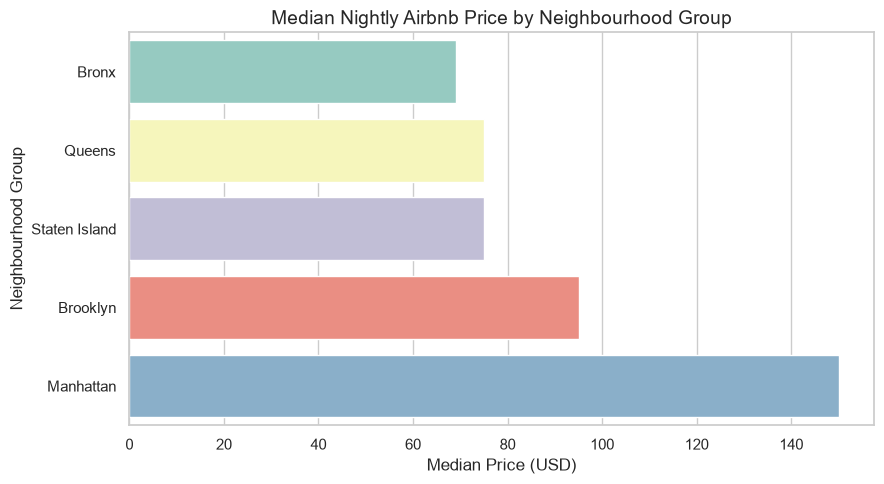

In [150]:
# %%
fig, ax = plt.subplots(figsize=(9, 5))

group_stats = df.groupby("neighbourhood_group")["price"].agg(["median", "std"])
group_stats = group_stats.sort_values("median")

sns.barplot(
    data=group_stats.reset_index(),
    y="neighbourhood_group",
    x="median",
    hue="neighbourhood_group",
    palette="Set3",
    legend=False,
    ax=ax
)

ax.set_title("Median Nightly Airbnb Price by Neighbourhood Group", fontsize=14)
ax.set_xlabel("Median Price (USD)")
ax.set_ylabel("Neighbourhood Group")

plt.tight_layout()
plt.savefig("charts/figure1_price_by_neighbourhood.png", dpi=120)
plt.show()

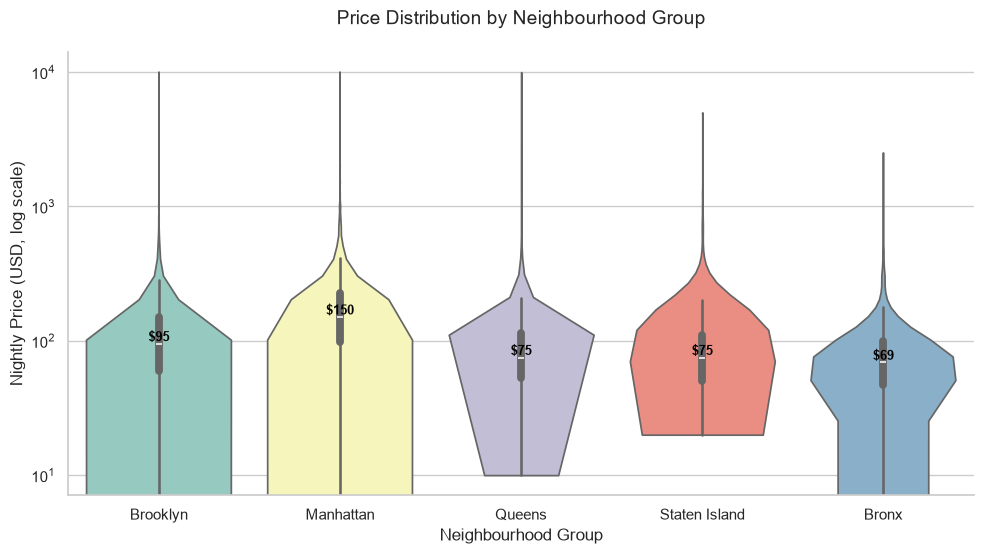

In [151]:
# %% [markdown]
# ### Figure 2 — Price Distribution by Neighbourhood Group

fig, ax = plt.subplots(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="neighbourhood_group",
    y="price",
    hue="neighbourhood_group",
    palette="Set3",
    dodge=False,
    inner="box",
    cut=0,
    density_norm="width",
    legend=False,
    ax=ax
)

# Compute medians
medians = df.groupby("neighbourhood_group")["price"].median()

# Adjust label placement dynamically
for tick, label in zip(ax.get_xticks(), ax.get_xticklabels()):
    group = label.get_text()
    median_val = medians[group]
    ax.text(
        tick,
        median_val,
        f"${median_val:.0f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
        color="black"
    )

# Log scale and layout tweaks
ax.set_yscale("log")
ax.set_title("Price Distribution by Neighbourhood Group", fontsize=14, pad=20)
ax.set_xlabel("Neighbourhood Group", fontsize=12)
ax.set_ylabel("Nightly Price (USD, log scale)", fontsize=12)

sns.despine()
plt.tight_layout(rect=[0, 0, 1, 0.95])  # leaves extra space for title
plt.savefig("charts/figure2_price_violin.png", dpi=120)
plt.show()



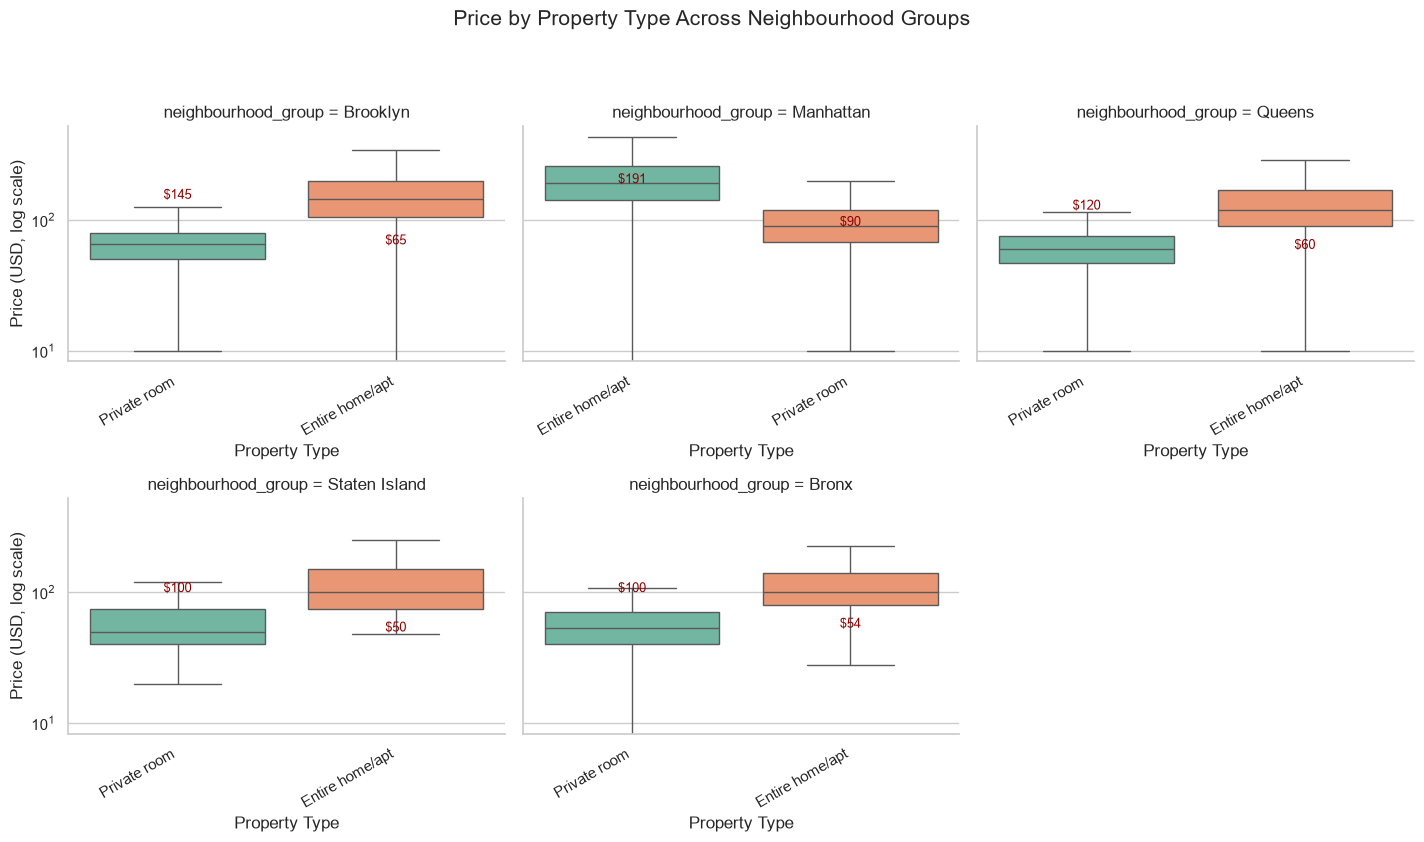

In [152]:
# %% [markdown]
# ### Figure 3 — Price by Property Type Across Neighbourhood Groups (FacetGrid + Medians)

# Compute medians for annotation
medians = df.groupby(["neighbourhood_group", "room_type"])["price"].median().unstack()

# FacetGrid visualization
g = sns.FacetGrid(
    df,
    col="neighbourhood_group",
    col_wrap=3,
    sharex=False,
    sharey=True,
    height=4,
    aspect=1.2
)

g.map_dataframe(
    sns.boxplot,
    x="room_type",
    y="price",
    hue="room_type",        # required when palette is used
    palette="Set2",
    dodge=False,
    showfliers=False,
    legend=False
)

for ax in g.axes.flat:
    ax.set_yscale("log")
    ax.set_xlabel("Property Type")
    ax.set_ylabel("Price (USD, log scale)")
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

    # Add median labels dynamically
    group = ax.get_title().split(" = ")[-1]
    if group in medians.index:
        for i, room in enumerate(medians.columns):
            val = medians.loc[group, room]
            if not np.isnan(val):
                ax.text(i, val * 1, f"${val:.0f}", ha="center", fontsize=9, color="darkred")

g.fig.suptitle("Price by Property Type Across Neighbourhood Groups", fontsize=15, y=1.05)

# subtitle = f"Dataset size: {len(df):,} listings • Loaded on {load_date}"
# g.fig.text(0.5, 0.02, subtitle, ha="center", fontsize=10)

sns.despine()
plt.tight_layout()
plt.savefig("charts/figure3_price_facet_enhanced.png", dpi=120)
plt.show()



---
## Summary & Interpretation

**Figure 1 - Median price by neighbourhood group.** Manhattan typically commands
the highest median nightly rate, followed by the outer boroughs, with the
variation between neighbourhoods reflecting demand, transportation access, and
tourist density. Lower median prices indicate more affordable or less centrally
located housing stock.

**Figure 2 - Price distribution by neighbourhood group.** The plot demonstrates 
pronounced right skew in Airbnb pricing across New York City. Manhattan and 
Brooklyn exhibit the widest distributions, driven by luxury listings, while outer 
boroughs remain tightly clustered around lower price points. The use of a 
logarithmic scale highlights the heavy‑tailed nature of the data, reinforcing the 
choice of the median as a robust measure of central tendency.

**Figure 3 - Price by property type.** The plots reveal strong price stratification 
across New York City boroughs and property types. Manhattan commands the highest 
median prices, while Staten Island and the Bronx remain the most affordable. The 
log scale highlights wide variability within boroughs, especially Manhattan, where
 entire apartments reach luxury price levels. In contrast, outer boroughs show 
 tighter distributions, indicating more uniform pricing. These patterns underscore 
 the influence of both location and property type on Airbnb pricing.

**What I learned.** The dataset captures the economics of short-term rentals
across NYC, with geography (neighbourhood group) and property type as the two
strongest predictors of price.

**Limitations.** The raw data contains missing neighbourhood labels and non-numeric
prices that require imputation; imputation assumes missing values are missing
at random, which may not always hold.

**Surprising / unclear.** Some neighbourhood groups have very few listings after
cleaning, which can make their statistics unstable, and cross-tabulation between
neighbourhood and property type is not broken out in these aggregate views.
